# Effnet B4

Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
                                            low_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074  

Train samples: 460
Val samples:   58
Test samples:  58

 

100%|██████████| 74.5M/74.5M [00:01<00:00, 47.7MB/s]



Starting training (EfficientNet-B4, frozen backbone)...
Image size: 380x380 | Batch size: 8

Epoch [01/30] | 21.5s | LR: 1.000000e-04 | Train Loss: 0.000226 | Val Loss: 0.000222 | Test Loss: 0.000209 | Val MAE: 0.016085 | Val RMSE: 0.021092 | Val R2: -0.267274
Epoch [02/30] | 25.4s | LR: 1.000000e-04 | Train Loss: 0.000189 | Val Loss: 0.000192 | Test Loss: 0.000200 | Val MAE: 0.014858 | Val RMSE: 0.019604 | Val R2: -0.094805
Epoch [03/30] | 25.4s | LR: 1.000000e-04 | Train Loss: 0.000177 | Val Loss: 0.000187 | Test Loss: 0.000195 | Val MAE: 0.014483 | Val RMSE: 0.019332 | Val R2: -0.064637
Epoch [04/30] | 25.9s | LR: 1.000000e-04 | Train Loss: 0.000161 | Val Loss: 0.000161 | Test Loss: 0.000172 | Val MAE: 0.013819 | Val RMSE: 0.017944 | Val R2: 0.082743
Epoch [05/30] | 25.4s | LR: 1.000000e-04 | Train Loss: 0.000153 | Val Loss: 0.000165 | Test Loss: 0.000175 | Val MAE: 0.013754 | Val RMSE: 0.018157 | Val R2: 0.060885
Epoch [06/30] | 25.4s | LR: 1.000000e-04 | Train Loss: 0.000143 | Va

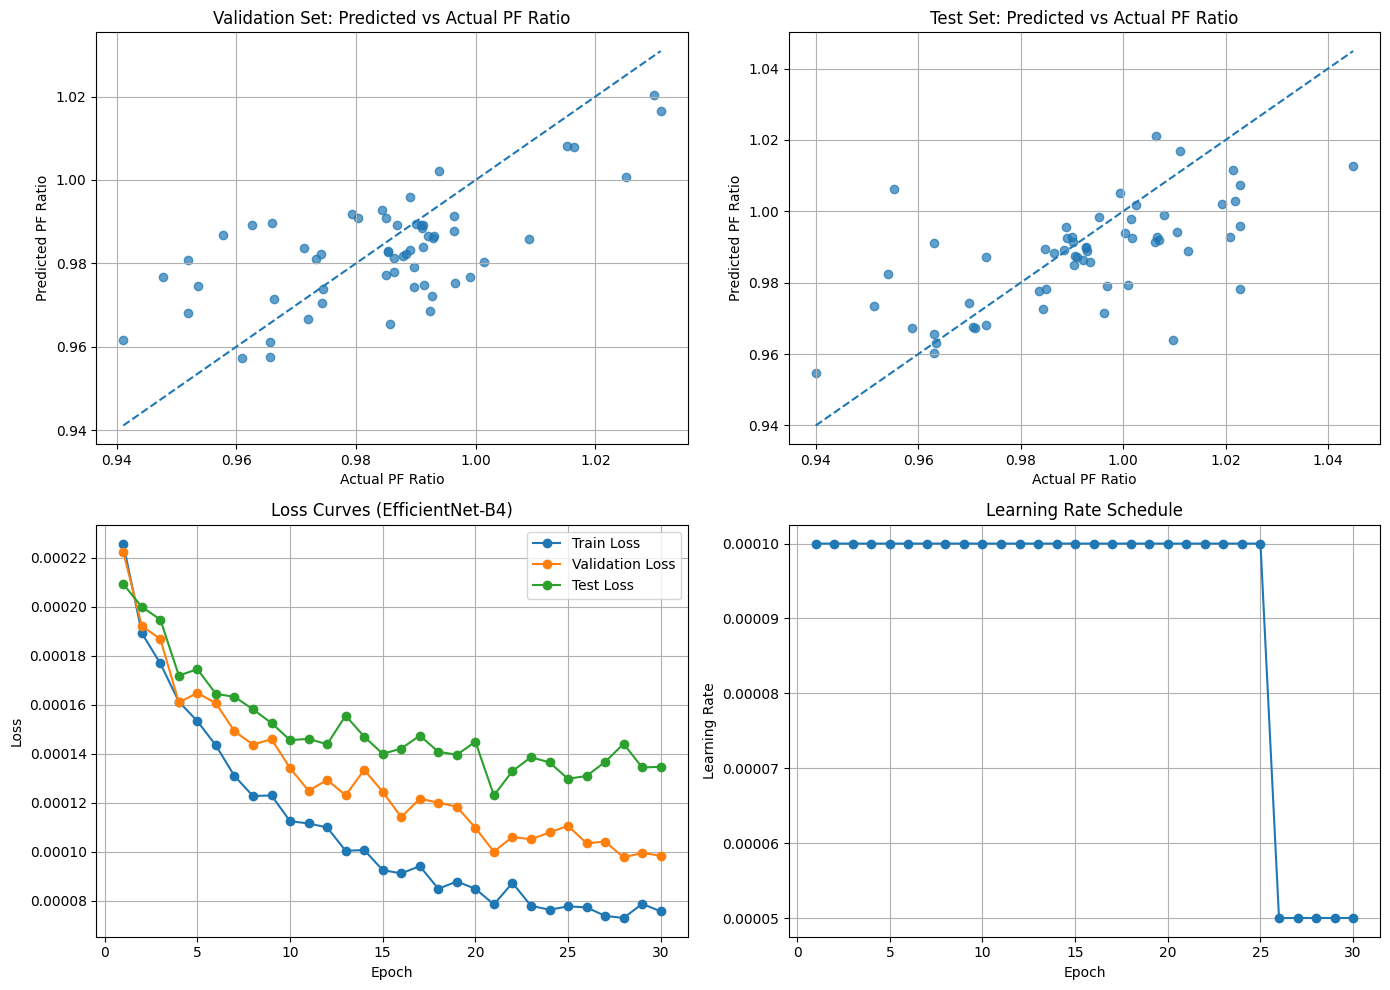


Saved:
- results_b4_frozen.png
- validation_predictions_b4.csv
- test_predictions_b4.csv

Model saved to: efficientnet_b4_dualreal_el_pf_ratio_best_val_model.pth


In [1]:
import os
import math
import copy
import random
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"          # original CSV file
IMAGE_SIZE = 380                 # B4 native resolution (vs 224 for B0)
BATCH_SIZE = 8                   # reduced from 16 — larger images use more VRAM
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
RANDOM_SEED = 42
NUM_WORKERS = 0   # use 0 first, especially on Windows/Jupyter
PRELOAD_TO_RAM = True            # cache all resized images in RAM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert relative paths like './EL/3903_35_1_01272020_20.tiff'
    into absolute paths based on the CSV/script directory.

    If add_wrp=True, convert:
    3903_35_1_01272020_20.tiff
    -> 3903_35_1_01272020_20_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    # Normalize slashes
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    # Add _wrp before file extension if needed
    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    # If already absolute, keep it
    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    # Remove leading ./ if present
    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load original CSV, compute PF ratio, resolve paths, and
    keep only valid rows with existing low/high EL files.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELLPath", "ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    # Convert power columns to numeric safely
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    # Remove invalid denominator
    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]

    # Remove invalid numerator
    df = df[df["Pmp_(W)"].notna()]

    # Compute PF ratio
    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # Resolve actual paths
    df["low_path"] = df["ELLPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))

    # Remove missing path strings
    df = df[df["low_path"].notna()]
    df = df[df["high_path"].notna()]

    # Keep only rows whose image files actually exist
    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    # Keep only needed columns
    keep_cols = ["low_path", "high_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=380, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = None

        if preload:
            self._preload_all()

    def _preload_all(self):
        """
        Read and resize every image once at init, store as uint8 in RAM.
        For 1400 samples at 380x380: ~1400 * 2 * 380 * 380 * 1 byte ≈ 385 MB
        """
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size / (1024 ** 2)
        print(f"\n  Preloading {n} samples ({n * 2} images) into RAM...")
        print(f"  Expected memory: ~{expected_mb:.0f} MB")
        t0 = time.time()

        self.cache_low = np.empty((n, self.image_size, self.image_size), dtype=np.uint8)
        self.cache_high = np.empty((n, self.image_size, self.image_size), dtype=np.uint8)

        failed = 0
        for i in range(n):
            row = self.df.iloc[i]
            try:
                self.cache_low[i] = self.resize_image(
                    self.read_grayscale_tiff(row["low_path"])
                )
                self.cache_high[i] = self.resize_image(
                    self.read_grayscale_tiff(row["high_path"])
                )
            except Exception as e:
                print(f"    Warning: failed to load sample {i}: {e}")
                self.cache_low[i] = 0
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_low.nbytes + self.cache_high.nbytes) / (1024 ** 2)
        print(f"  Done in {elapsed:.1f}s | RAM used: {mem_mb:.1f} MB | Failed: {failed}")

        self.cache = True

    def read_grayscale_tiff(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Failed to load image: {path}")

        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
        )

    def apply_same_augmentation(self, low_img, high_img):
        """
        Keep augmentation identical for low/high pair.
        Keep it light for EL images.
        """
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ----- Load images: from cache or from disk -----
        if self.cache:
            low_img = self.cache_low[idx].copy()
            high_img = self.cache_high[idx].copy()
        else:
            low_img = self.read_grayscale_tiff(row["low_path"])
            high_img = self.read_grayscale_tiff(row["high_path"])
            low_img = self.resize_image(low_img)
            high_img = self.resize_image(high_img)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        # Normalize to [0, 1]
        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # stack -> [2, H, W]
        x = np.concatenate([low_img, high_img], axis=0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y


class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


# =========================================================
# MODEL
# =========================================================
def build_efficientnet_b4_2ch(pretrained=True):
    """
    EfficientNet-B4 modified to accept 2-channel input
    and output 1 regression value.

    B4 vs B0:
    - Native input:  380x380 (vs 224x224)
    - Parameters:    ~19M    (vs ~5.3M)
    - Classifier in: 1792    (vs 1280)
    """
    if pretrained:
        weights = models.EfficientNet_B4_Weights.DEFAULT
    else:
        weights = None

    model = models.efficientnet_b4(weights=weights)

    # Replace first conv: 3ch -> 2ch
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        if pretrained:
            old_weights = old_conv.weight  # [out_channels, 3, k, k]
            new_conv.weight[:, 0, :, :] = old_weights[:, 0, :, :]
            new_conv.weight[:, 1, :, :] = old_weights[:, 1, :, :]
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

    model.features[0][0] = new_conv

    # Replace classifier head
    in_features = model.classifier[1].in_features  # 1792 for B4
    model.classifier[1] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


# =========================================================
# PLOTTING HELPERS
# =========================================================
def plot_scatter(ax, trues, preds, title):
    ax.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True)


# =========================================================
# MAIN
# =========================================================
def main():
    # -------------------------
    # Prepare dataframe
    # -------------------------
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering for 0.8/0.1/0.1 split.")

    print("\nSample rows:")
    print(df.head())

    # -------------------------
    # Train / validation / test split
    # 0.8 / 0.1 / 0.1
    # -------------------------
    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # -------------------------
    # Dataset / loader
    # -------------------------
    train_dataset = DualELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = DualELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = DualELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_efficientnet_b4_2ch(pretrained=True).to(DEVICE)

    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

    # Only train classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    # Scheduler: reduce LR when validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    # -------------------------
    # Train loop
    # -------------------------
    train_losses = []
    val_losses = []
    test_losses = []

    train_maes = []
    val_maes = []
    test_maes = []

    learning_rates = []

    print(f"\n{'='*70}")
    print("Starting training (EfficientNet-B4, frozen backbone)...")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'='*70}\n")
    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()
        current_lr = optimizer.param_groups[0]["lr"]
        learning_rates.append(current_lr)

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        # scheduler step based on validation loss
        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_maes.append(train_mae)
        val_maes.append(val_mae)
        test_maes.append(test_mae)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"LR: {current_lr:.6e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        # Best model based on validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time/60:.1f} min)")

    # -------------------------
    # Final evaluation using best validation model
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print("\nBest Model Performance (selected by Validation RMSE)")
    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    # -------------------------
    # Plotting
    # -------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Scatter: Validation
    plot_scatter(
        axes[0, 0],
        val_trues,
        val_preds,
        "Validation Set: Predicted vs Actual PF Ratio"
    )

    # Scatter: Test
    plot_scatter(
        axes[0, 1],
        test_trues,
        test_preds,
        "Test Set: Predicted vs Actual PF Ratio"
    )

    # Loss curves
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker="o")
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss", marker="o")
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), test_losses, label="Test Loss", marker="o")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("Loss Curves (EfficientNet-B4)")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Learning rate curve
    axes[1, 1].plot(range(1, NUM_EPOCHS + 1), learning_rates, marker="o")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("Learning Rate Schedule")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("results_b4_frozen.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------
    # Save prediction tables
    # -------------------------
    val_results_df = pd.DataFrame({
        "actual_pf_ratio": val_trues,
        "predicted_pf_ratio": val_preds
    })
    val_results_df.to_csv("validation_predictions_b4.csv", index=False)

    test_results_df = pd.DataFrame({
        "actual_pf_ratio": test_trues,
        "predicted_pf_ratio": test_preds
    })
    test_results_df.to_csv("test_predictions_b4.csv", index=False)

    print("\nSaved:")
    print("- results_b4_frozen.png")
    print("- validation_predictions_b4.csv")
    print("- test_predictions_b4.csv")

    # -------------------------
    # Save model
    # -------------------------
    save_path = "efficientnet_b4_dualreal_el_pf_ratio_best_val_model.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")


if __name__ == "__main__":
    main()

# ConvNext Unfrozen

Using device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
                                            low_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.944074  

Train samples: 460
Val samples:   58
Test samples:  58

 

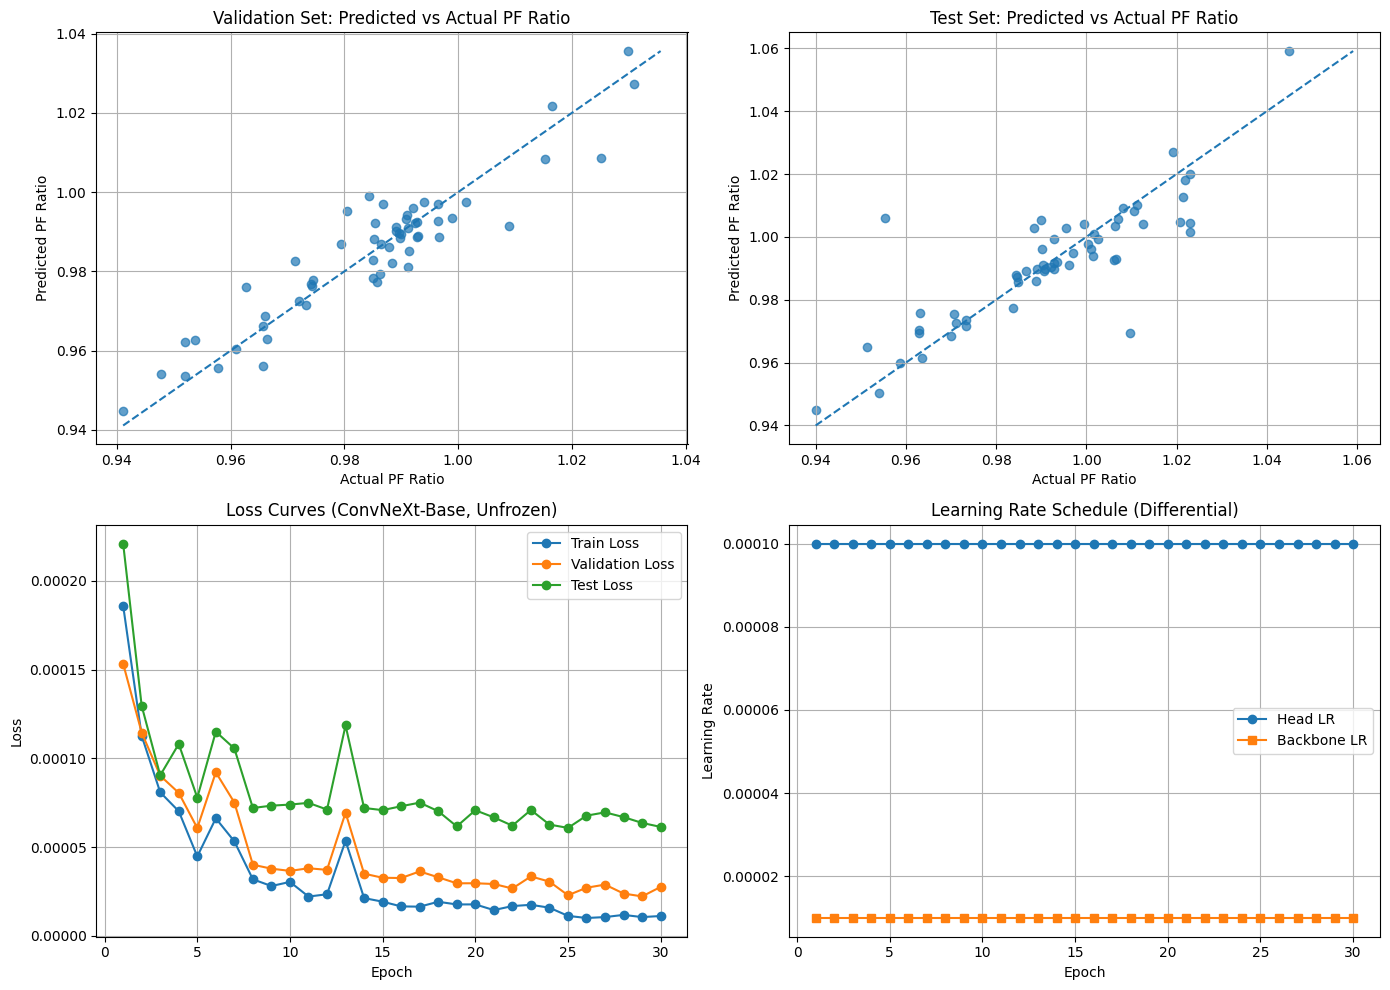


Saved:
- results_convnext_base_unfrozen.png
- validation_predictions_convnext_unfrozen.csv
- test_predictions_convnext_unfrozen.csv

Model saved to: convnext_base_unfrozen_dualreal_el_pf_ratio_best_val_model.pth


In [ ]:
import os
import math
import copy
import random
import time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"          # original CSV file
IMAGE_SIZE = 224                 # ConvNeXt-Base native resolution
BATCH_SIZE = 8                   # reduced from 16 — full backprop uses more VRAM
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4             # classifier head learning rate
BACKBONE_LR = 1e-5               # backbone learning rate (10x lower)
RANDOM_SEED = 42
NUM_WORKERS = 0   # use 0 first, especially on Windows/Jupyter
PRELOAD_TO_RAM = True            # cache all resized images in RAM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert relative paths like './EL/3903_35_1_01272020_20.tiff'
    into absolute paths based on the CSV/script directory.

    If add_wrp=True, convert:
    3903_35_1_01272020_20.tiff
    -> 3903_35_1_01272020_20_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    # Normalize slashes
    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    # Add _wrp before file extension if needed
    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    # If already absolute, keep it
    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    # Remove leading ./ if present
    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load original CSV, compute PF ratio, resolve paths, and
    keep only valid rows with existing low/high EL files.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELLPath", "ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    # Convert power columns to numeric safely
    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    # Remove invalid denominator
    df = df[df["Nameplate_Pmp_(W)"].notna()]
    df = df[df["Nameplate_Pmp_(W)"] > 0]

    # Remove invalid numerator
    df = df[df["Pmp_(W)"].notna()]

    # Compute PF ratio
    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    # Resolve actual paths
    df["low_path"] = df["ELLPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))

    # Remove missing path strings
    df = df[df["low_path"].notna()]
    df = df[df["high_path"].notna()]

    # Keep only rows whose image files actually exist
    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    # Keep only needed columns
    keep_cols = ["low_path", "high_path", "pf_ratio"]
    optional_id_cols = [c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"] if c in df.columns]
    keep_cols = optional_id_cols + keep_cols

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = None

        if preload:
            self._preload_all()

    def _preload_all(self):
        """
        Read and resize every image once at init, store as uint8 in RAM.
        For 1400 samples at 224x224: ~1400 * 2 * 224 * 224 * 1 byte ≈ 134 MB
        """
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size / (1024 ** 2)
        print(f"\n  Preloading {n} samples ({n * 2} images) into RAM...")
        print(f"  Expected memory: ~{expected_mb:.0f} MB")
        t0 = time.time()

        self.cache_low = np.empty((n, self.image_size, self.image_size), dtype=np.uint8)
        self.cache_high = np.empty((n, self.image_size, self.image_size), dtype=np.uint8)

        failed = 0
        for i in range(n):
            row = self.df.iloc[i]
            try:
                self.cache_low[i] = self.resize_image(
                    self.read_grayscale_tiff(row["low_path"])
                )
                self.cache_high[i] = self.resize_image(
                    self.read_grayscale_tiff(row["high_path"])
                )
            except Exception as e:
                print(f"    Warning: failed to load sample {i}: {e}")
                self.cache_low[i] = 0
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_low.nbytes + self.cache_high.nbytes) / (1024 ** 2)
        print(f"  Done in {elapsed:.1f}s | RAM used: {mem_mb:.1f} MB | Failed: {failed}")

        self.cache = True

    def read_grayscale_tiff(self, path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise ValueError(f"Failed to load image: {path}")

        return img

    def resize_image(self, img):
        return cv2.resize(
            img,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_LINEAR
        )

    def apply_same_augmentation(self, low_img, high_img):
        """
        Keep augmentation identical for low/high pair.
        Keep it light for EL images.
        """
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ----- Load images: from cache or from disk -----
        if self.cache:
            low_img = self.cache_low[idx].copy()
            high_img = self.cache_high[idx].copy()
        else:
            low_img = self.read_grayscale_tiff(row["low_path"])
            high_img = self.read_grayscale_tiff(row["high_path"])
            low_img = self.resize_image(low_img)
            high_img = self.resize_image(high_img)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        # Normalize to [0, 1]
        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        # [H, W] -> [1, H, W]
        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # stack -> [2, H, W]
        x = np.concatenate([low_img, high_img], axis=0)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row["pf_ratio"], dtype=torch.float32)

        return x, y


class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


# =========================================================
# MODEL
# =========================================================
def build_convnext_base_2ch(pretrained=True):
    """
    ConvNeXt-Base modified to accept 2-channel input
    and output 1 regression value.

    ConvNeXt-Base architecture:
    - Native input:  224x224
    - Parameters:    ~88M
    - Stem conv:     features[0][0] = Conv2d(3, 128, kernel_size=4, stride=4)
    - Classifier:    classifier[2] = Linear(1024, 1000)
    """
    if pretrained:
        weights = models.ConvNeXt_Base_Weights.DEFAULT
    else:
        weights = None

    model = models.convnext_base(weights=weights)

    # ---- Replace stem conv: 3ch -> 2ch ----
    # ConvNeXt stem: features[0][0] is Conv2d(3, 128, 4, 4)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=(old_conv.bias is not None)
    )

    with torch.no_grad():
        if pretrained:
            # Copy weights from first 2 of 3 input channels
            old_weights = old_conv.weight  # [128, 3, 4, 4]
            new_conv.weight[:, 0, :, :] = old_weights[:, 0, :, :]
            new_conv.weight[:, 1, :, :] = old_weights[:, 1, :, :]
            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

    model.features[0][0] = new_conv

    # ---- Replace classifier head ----
    # ConvNeXt classifier: Sequential(LayerNorm2d, Flatten, Linear(1024, 1000))
    in_features = model.classifier[2].in_features  # 1024 for Base
    model.classifier[2] = BoundedOutput(in_features, min_val=0.80, max_val=1.20)

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, np.array(preds), np.array(trues)


# =========================================================
# PLOTTING HELPERS
# =========================================================
def plot_scatter(ax, trues, preds, title):
    ax.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True)


# =========================================================
# MAIN
# =========================================================
def main():
    # -------------------------
    # Prepare dataframe
    # -------------------------
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering for 0.8/0.1/0.1 split.")

    print("\nSample rows:")
    print(df.head())

    # -------------------------
    # Train / validation / test split
    # 0.8 / 0.1 / 0.1
    # -------------------------
    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    # -------------------------
    # Dataset / loader
    # -------------------------
    train_dataset = DualELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = DualELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = DualELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS
    )

    # -------------------------
    # Model
    # -------------------------
    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    # All parameters are trainable (no freezing)
    # Use differential learning rates:
    #   - backbone (features): lower LR to preserve pretrained knowledge
    #   - classifier head:     higher LR to learn the new task
    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW([
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": LEARNING_RATE},
    ], weight_decay=1e-2)

    # Scheduler: reduce LR when validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    # -------------------------
    # Train loop
    # -------------------------
    train_losses = []
    val_losses = []
    test_losses = []

    train_maes = []
    val_maes = []
    test_maes = []

    learning_rates = []
    backbone_lrs = []

    print(f"\n{'='*70}")
    print("Starting training (ConvNeXt-Base, UNFROZEN backbone, differential LR)...")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'='*70}\n")
    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()
        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]
        backbone_lrs.append(current_backbone_lr)
        learning_rates.append(current_head_lr)

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        # scheduler step based on validation loss
        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_maes.append(train_mae)
        val_maes.append(val_mae)
        test_maes.append(test_mae)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        # Best model based on validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time/60:.1f} min)")

    # -------------------------
    # Final evaluation using best validation model
    # -------------------------
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print("\nBest Model Performance (selected by Validation RMSE)")
    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    # -------------------------
    # Plotting
    # -------------------------
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Scatter: Validation
    plot_scatter(
        axes[0, 0],
        val_trues,
        val_preds,
        "Validation Set: Predicted vs Actual PF Ratio"
    )

    # Scatter: Test
    plot_scatter(
        axes[0, 1],
        test_trues,
        test_preds,
        "Test Set: Predicted vs Actual PF Ratio"
    )

    # Loss curves
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), train_losses, label="Train Loss", marker="o")
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), val_losses, label="Validation Loss", marker="o")
    axes[1, 0].plot(range(1, NUM_EPOCHS + 1), test_losses, label="Test Loss", marker="o")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("Loss Curves (ConvNeXt-Base, Unfrozen)")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Learning rate curves (both backbone and head)
    axes[1, 1].plot(range(1, NUM_EPOCHS + 1), learning_rates, marker="o", label="Head LR")
    axes[1, 1].plot(range(1, NUM_EPOCHS + 1), backbone_lrs, marker="s", label="Backbone LR")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("Learning Rate Schedule (Differential)")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig("results_convnext_base_unfrozen.png", dpi=300, bbox_inches="tight")
    plt.show()

    # -------------------------
    # Save prediction tables
    # -------------------------
    val_results_df = pd.DataFrame({
        "actual_pf_ratio": val_trues,
        "predicted_pf_ratio": val_preds
    })
    val_results_df.to_csv("validation_predictions_convnext_unfrozen.csv", index=False)

    test_results_df = pd.DataFrame({
        "actual_pf_ratio": test_trues,
        "predicted_pf_ratio": test_preds
    })
    test_results_df.to_csv("test_predictions_convnext_unfrozen.csv", index=False)

    print("\nSaved:")
    print("- results_convnext_base_unfrozen.png")
    print("- validation_predictions_convnext_unfrozen.csv")
    print("- test_predictions_convnext_unfrozen.csv")

    # -------------------------
    # Save model
    # -------------------------
    save_path = "convnext_base_unfrozen_dualreal_el_pf_ratio_best_val_model.pth"
    torch.save(model.state_dict(), save_path)
    print(f"\nModel saved to: {save_path}")


if __name__ == "__main__":
    main()